# GRU Gated ESN
In this notebook we are going to explore a new hybrid model of gating in the $h_t$ of a ESN into a GRU in different ways.

In [40]:
#imports
import wandb
from my_engine.sweep import make_train_sweep
from torch.utils.data import TensorDataset
from my_engine.data import get_dataloaders
from src.my_engine.sweep import terminate_sweep, get_best_sweep_run_and_config
from src.my_engine.config import ModelConfig, TrainerConfig, MetricsConfig
from src.my_engine.utils import build_model, make_optimizer, get_direction_accuracy
from src.my_engine.trainer import Trainer
from src.my_engine.data import TimeSeriesDataset
from src.my_engine.financial_data import make_single_stock_df
import yfinance as yf
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
import os

In [2]:
%load_ext autoreload
%autoreload 2

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.chdir("/home/alexsearle/Documents/Bucknell/SP26/csci357_final_project")

In [3]:
msft = yf.download('MSFT', period="5y")
msft['log_returns'] = np.log(msft['Close'] / msft['Close'].shift(1))
msft['log_volume'] = np.log(msft['Volume'])
msft.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [4]:
val_idx = int(len(msft) * 0.8)
train_df = msft.iloc[:val_idx]
test_df = msft.iloc[val_idx:]

train_ds = TimeSeriesDataset(train_df['log_returns'].values, 30, 1)
test_ds = TimeSeriesDataset(test_df['log_returns'].values, 30, 1)

## Testing Gated ESN GRU

In [5]:
gated_esn_gru_config = ModelConfig(
    model_type="gated_esn_gru",
    reservoir_size=500,
    reservoir_sparsity=0.99,
    leak_rate=0.8,
)

gated_esn_model = build_model(input_spec=1, config=gated_esn_gru_config, num_outputs=1)

trainer_config = TrainerConfig(
    optimizer_name="adam",
    learning_rate=1e-3,
    weight_decay=1e-5,
    device=device,
    num_epochs=100,
    trainer_batch_size=64,
    evaluator_batch_size=128,
    early_stopping_patience=None,
)

train_loader, test_loader, _ = get_dataloaders(
    train_ds=train_ds,
    eval_ds=test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
    time_series=True,
)

with Trainer(
    model=gated_esn_model,
    config=trainer_config,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, gated_esn_model.parameters()), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=0.0032,Val Loss=0.0008, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0032, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0443, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0008, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0253, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=0.0006,Val Loss=0.0004, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0006, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0192, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0004, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0150, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=0.0004,Val Loss=0.0002, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0004, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0160, device='cuda:0')}, Test: {'MeanSquaredErr

In [6]:
gru_config = ModelConfig(
    model_type="rnn",
    rnn_type="gru",
)

gru_model = build_model(input_spec=1, config=gru_config, num_outputs=1)

with Trainer(
    model=gru_model,
    config=trainer_config,
    optimizer=make_optimizer(gru_model.parameters(), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=0.0004,Val Loss=0.0002, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0004, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0159, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0002, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0111, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=0.0003,Val Loss=0.0002, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0003, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0137, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0002, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0106, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=0.0003,Val Loss=0.0002, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0003, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0131, device='cuda:0')}, Test: {'MeanSquaredErr

In [7]:
stepwise_config = ModelConfig(
    model_type="stepwise_esn_gated_gru",
    leak_rate=0.5
)

stepwise_model = build_model(input_spec=1, config=stepwise_config, num_outputs=1)

with Trainer(
    model=stepwise_model,
    config=trainer_config,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, stepwise_model.parameters()), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=0.0033,Val Loss=0.0007, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0033, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0444, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0007, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0239, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=0.0007,Val Loss=0.0003, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0007, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0218, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.0003, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0125, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=0.0004,Val Loss=0.0002, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(0.0004, device='cuda:0'), 'MeanAbsoluteError': tensor(0.0160, device='cuda:0')}, Test: {'MeanSquaredErr

## Testing with more features

In [5]:
msft = yf.download('MSFT', period="5y")
msft['log_returns'] = np.log(msft['Close'].shift(1) / msft['Close'])
msft['log_volume'] = np.log(msft['Volume'])
msft['log_intraday_chng'] = np.log(msft['High'] / msft['Low'])
msft['log_variance'] = msft['log_intraday_chng'].rolling(5).mean()
msft['10_log_returns_ma'] = msft['log_returns'].rolling(10).mean()
msft['20_log_returns_ma'] = msft['log_returns'].rolling(20).mean()
msft['50_log_returns_ma'] = msft['log_returns'].rolling(50).mean()

msft.dropna(inplace=True)

val_idx = int(len(msft) * 0.8)
train_df = msft.iloc[:val_idx]
test_df = msft.iloc[val_idx:]

[*********************100%***********************]  1 of 1 completed


In [6]:
features = ['log_returns', 'log_volume', 'log_intraday_chng', 'log_variance', '10_log_returns_ma', '20_log_returns_ma', '50_log_returns_ma']
scaler = StandardScaler()

train_scaled = pd.DataFrame(scaler.fit_transform(train_df[features]), columns=train_df[features].columns)
test_scaled = pd.DataFrame(scaler.transform(test_df[features]), columns=test_df[features].columns)

In [7]:
WINDOW_SIZE = 50
target = 'log_returns'


X = []
y = []
for i in range(train_scaled.shape[0] - WINDOW_SIZE - 1):
    data = train_scaled.iloc[i:i+WINDOW_SIZE][features]
    y_temp = train_scaled.iloc[i+WINDOW_SIZE][target]
    X.append(data)
    y.append(y_temp)
X = np.array(X)
y = np.array(y)
train_ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))

X = []
y = []
for i in range(test_scaled.shape[0] - WINDOW_SIZE - 1):
    data = test_scaled.iloc[i:i+WINDOW_SIZE][features]
    y_temp = test_scaled.iloc[i+WINDOW_SIZE][target]
    X.append(data)
    y.append(y_temp)
X = np.array(X)
y = np.array(y)
test_ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
print(X.shape)

(190, 50, 7)


In [90]:
gated_esn_gru_config = ModelConfig(
    model_type="gated_esn_gru",
    reservoir_size=500,
    reservoir_sparsity=0.9,
    leak_rate=0.8,
)

gated_esn_model = build_model(input_spec=len(features), config=gated_esn_gru_config, num_outputs=1)

trainer_config = TrainerConfig(
    optimizer_name="adam",
    learning_rate=5e-4,
    weight_decay=1e-4,
    device=device,
    num_epochs=200,
    trainer_batch_size=64,
    evaluator_batch_size=128,
    early_stopping_patience=None,
)

train_loader, test_loader, _ = get_dataloaders(
    train_ds=train_ds,
    eval_ds=test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
    time_series=True,
)

with Trainer(
    model=gated_esn_model,
    config=trainer_config,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, gated_esn_model.parameters()), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0478,Val Loss=0.9006, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0478, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7517, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9006, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6533, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0269,Val Loss=0.8886, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0269, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7463, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8886, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6511, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0195,Val Loss=0.8907, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

In [105]:
gru_config = ModelConfig(
    model_type="rnn",
    rnn_type="gru",
    rnn_hidden_size=128,
    rnn_num_layers=2
)

trainer_config = TrainerConfig(
    optimizer_name="adam",
    learning_rate=5e-4,
    weight_decay=5e-4,
    device=device,
    num_epochs=50,
    trainer_batch_size=64,
    evaluator_batch_size=128,
    early_stopping_patience=None,
)

gru_model = build_model(input_spec=len(features), config=gru_config, num_outputs=1)

with Trainer(
    model=gru_model,
    config=trainer_config,
    optimizer=make_optimizer(gru_model.parameters(), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0440,Val Loss=0.8920, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0440, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7483, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8920, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6481, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0407,Val Loss=0.8948, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0407, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7468, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8948, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6490, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0398,Val Loss=0.8993, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0398, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7460, device='cuda:0')}, Test: {'MeanSquaredErr

In [92]:
trainer_config = TrainerConfig(
    optimizer_name="adam",
    learning_rate=5e-4,
    weight_decay=1e-4,
    device=device,
    num_epochs=1000,
    trainer_batch_size=64,
    evaluator_batch_size=128,
    early_stopping_patience=None,
)

stepwise_config = ModelConfig(
    model_type="stepwise_esn_gated_gru",
    leak_rate=0.2,
    reservoir_size=100,
    reservoir_sparsity=0.95,
    spectral_radius=1,
    rnn_hidden_size=128
)

stepwise_model = build_model(input_spec=len(features), config=stepwise_config, num_outputs=1)

with Trainer(
    model=stepwise_model,
    config=trainer_config,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, stepwise_model.parameters()), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0440,Val Loss=0.9013, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0440, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7480, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9013, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6513, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0301,Val Loss=0.9165, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0301, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7426, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9165, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6563, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0284,Val Loss=0.9078, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0284, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7425, device='cuda:0')}, Test: {'MeanSquaredErr

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(results['train_losses'], label="Train Loss")
plt.plot(results['val_losses'], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [ ]:
print(min(results['val_losses']))

In [111]:
trainer_config = TrainerConfig(
    optimizer_name="adam",
    learning_rate=5e-4,
    weight_decay=7e-4,
    device=device,
    num_epochs=50,
    trainer_batch_size=64,
    evaluator_batch_size=128,
    early_stopping_patience=None,
    use_scheduler=True,
)

deep_config = ModelConfig(
    model_type="deep_esn_gated_gru",
    leak_rate=0.2,
    reservoir_size=1000,
    reservoir_sparsity=0.95,
    spectral_radius=1,
    rnn_hidden_size=128,
    hidden_units=[128, 128, 128]
)

deep_model = build_model(input_spec=len(features), config=deep_config, num_outputs=1)

with Trainer(
    model=deep_model,
    config=trainer_config,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, deep_model.parameters()), trainer_config),
    criterion=torch.nn.MSELoss(),
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0813,Val Loss=0.9181, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0813, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7636, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9181, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6607, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0827,Val Loss=0.8865, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0827, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7580, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8865, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6533, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0500,Val Loss=0.9332, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

In [112]:
dir_acc_deep = get_direction_accuracy(deep_model, test_loader, scaler, features.index('log_returns'))
print(f"Directional accuracy: {dir_acc_deep}")

Directional accuracy: 0.5392670157068062


In [106]:
dir_acc_gru = get_direction_accuracy(gru_model, test_loader, scaler, features.index('log_returns'))
print(f"Directional accuracy: {dir_acc_gru}")

Directional accuracy: 0.5340314136125655


In [76]:
msft['log_returns'].min()

np.float64(-0.09652475081840167)

In [113]:
scaler.n_features_in_

7

In [122]:
# Define the sweep configuration
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "model_type": {"value": "deep_esn_gated_gru"},
        "learning_rate": {"min": 1e-5, "max": 1e-2, "distribution": "log_uniform_values"},
        "weight_decay": {"min": 1e-6, "max": 1e-3, "distribution": "log_uniform_values"},
        "reservoir_size": {"values": [500, 1000, 1500]},
        "spectral_radius": {"min": 0.5, "max": 1.5, "distribution": "log_uniform_values"},
        "reservoir_sparsity": {"min": 0.8, "max": 0.99, "distribution": "log_uniform_values"},
        "leak_rate": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "input_scale": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "rnn_hidden_size": {"values": [64, 128, 256]},
        "hidden_units": {"values": [[128, 128, 128], [256, 256], [512], [128, 128], [256, 256, 256]]},
        "trainer_batch_size": {"values": [32, 64, 128]},
        "num_epochs": {"value": 50},
        "loss_name": {"value": "mse"},
        "early_stopping_min_delta": {"value": 1e-6},
        "early_stopping_patience": {"value": 10},
        "use_scheduler": {"value": True},
    }
}

# Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project="gated-esn-gru-sweeps")

# Create the training function for the sweep
train_sweep = make_train_sweep(
    wandb_project_name="gated-esn-gru-sweeps",
    datasets=(train_ds, test_ds),
    device=device,
    input_spec=len(features),
    num_outputs=1,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
)

# Run the sweep agent
wandb.agent(sweep_id, function=train_sweep, count=80)

Create sweep with ID: 2uk9uhgf
Sweep URL: https://wandb.ai/sas073-bucknell-university/gated-esn-gru-sweeps/sweeps/2uk9uhgf


wandb: Agent Starting Run: mw8uuyq0 with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [256, 256]
wandb: 	input_scale: 0.1688685224618608
wandb: 	leak_rate: 0.5491645278675831
wandb: 	learning_rate: 9.768939958913314e-05
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 1000
wandb: 	reservoir_sparsity: 0.9569405794362472
wandb: 	rnn_hidden_size: 64
wandb: 	spectral_radius: 0.6272676166343433
wandb: 	trainer_batch_size: 32
wandb: 	use_scheduler: True
wandb: 	weight_decay: 2.8421883831084625e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [256, 256], 'input_scale': 0.1688685224618608, 'leak_rate': 0.5491645278675831, 'learning_rate': 9.768939958913314e-05, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 1000, 'reservoir_sparsity': 0.9569405794362472, 'rnn_hidden_size': 64, 'spectral_radius': 0.6272676166343433, 'trainer_batch_size': 32, 'use_scheduler': True, 'weight_decay': 2.8421883831084625e-05}
Run name set to: deep_esn_gated_gru_bs32_lr0.00010_h256x256_wd0.00003_m0.90
deep_esn_gated_gru


wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_patience' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'reservoir_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'spectral_radius' was locked by 'sweep'

Epoch 0: Train Loss=1.0500,Val Loss=0.9068, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0500, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7488, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9068, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6519, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0348,Val Loss=0.9183, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0348, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7442, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9183, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6627, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0270,Val Loss=0.9297, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0269, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7426, device='cuda:0')}, Test: {'MeanSquaredErr

...

wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [128, 128], 'input_scale': 0.13253716894438203, 'leak_rate': 0.13533436735958487, 'learning_rate': 0.001477448588954245, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 500, 'reservoir_sparsity': 0.8969223256522806, 'rnn_hidden_size': 256, 'spectral_radius': 0.6237846262538962, 'trainer_batch_size': 32, 'use_scheduler': True, 'weight_decay': 0.0001934007109132455}
Run name set to: deep_esn_gated_gru_bs32_lr0.00148_h128x128_wd0.00019_m0.90
deep_esn_gated_gru
Epoch 0: Train Loss=1.0653,Val Loss=0.9051, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0653, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7561, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9051, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6568, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--

wandb: Agent Starting Run: 7qni8qvt with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [256, 256, 256]
wandb: 	input_scale: 0.22660908989077075
wandb: 	leak_rate: 0.4363042794012788
wandb: 	learning_rate: 3.3975628438979647e-05
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 1500
wandb: 	reservoir_sparsity: 0.8887335781716548
wandb: 	rnn_hidden_size: 256
wandb: 	spectral_radius: 0.8666774853960341
wandb: 	trainer_batch_size: 128
wandb: 	use_scheduler: True
wandb: 	weight_decay: 1.8484624453832765e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [256, 256, 256], 'input_scale': 0.22660908989077075, 'leak_rate': 0.4363042794012788, 'learning_rate': 3.3975628438979647e-05, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 1500, 'reservoir_sparsity': 0.8887335781716548, 'rnn_hidden_size': 256, 'spectral_radius': 0.8666774853960341, 'trainer_batch_size': 128, 'use_scheduler': True, 'weight_decay': 1.8484624453832765e-06}
Run name set to: deep_esn_gated_gru_bs128_lr0.00003_h256x256x256_wd0.00000_m0.90
deep_esn_gated_gru


wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_patience' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'reservoir_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'spectral_radius' was locked by 'sweep'

Epoch 0: Train Loss=1.0499,Val Loss=0.8983, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0499, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7513, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8983, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6510, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0310,Val Loss=0.9066, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0310, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7444, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9066, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6521, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0240,Val Loss=0.9080, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0240, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7404, device='cuda:0')}, Test: {'MeanSquaredErr

In [123]:
terminate_sweep(sweep_id)
deep_sweep_id = sweep_id

Sweep 2uk9uhgf current state is: RUNNING
Stopping sweep sas073-bucknell-university/gated-esn-gru-sweeps/2uk9uhgf


Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/gated-esn-gru-sweeps/2uk9uhgf


Sweep sas073-bucknell-university/gated-esn-gru-sweeps/2uk9uhgf stopped successfully


wandb: Done.


In [127]:
best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project="gated-esn-gru-sweeps",
    sweep_id=deep_sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
print(best_config)

deep_esn_gated_gru_bs64_lr0.00021_h256x256x256_wd0.00036_m0.90
0.873377799987793
{'device': 'cuda', 'dropout': [0.1, 0.2], 'metrics': None, 'use_GAP': False, 'momentum': 0.9, 'rnn_type': 'rnn', 'leak_rate': 0.2805768681933345, 'loss_name': 'mse', 'num_heads': 4, 'clip_value': 0, 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'pin_memory': True, 'vocab_size': 0, 'conv_blocks': [], 'in_channels': 1, 'input_scale': 0.13591115251956526, 'max_seq_len': None, 'num_filters': 100, 'num_workers': 2, 'padding_idx': 0, 'filter_sizes': [3, 4, 5], 'hidden_units': [256, 256, 256], 'weight_decay': 0.00035641805724613795, 'bidirectional': False, 'embedding_dim': 100, 'learning_rate': 0.00020878453746511224, 'use_scheduler': True, 'checkpoint_dir': './checkpoints', 'clip_grad_norm': 0, 'num_parameters': 11220277, 'optimizer_name': 'Adam', 'reservoir_size': 1500, 'rnn_num_layers': 1, 'scheduler_type': 'reduce_on_plateau', 'dim_feedforward': 512, 'rnn_hidden_size': 256, 'scheduler_gamma': 0.1, 'sp

In [219]:
deep_best_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
    rnn_hidden_size=best_config['rnn_hidden_size']
)

best_deep_model = build_model(input_spec=len(features), config=deep_best_config, num_outputs=1)

deep_best_trainer_config = TrainerConfig(
    optimizer_name=best_config['optimizer_name'],
    learning_rate=best_config['learning_rate'],
    weight_decay=best_config['weight_decay'],
    use_scheduler=best_config['use_scheduler'],
    early_stopping_min_delta=best_config['early_stopping_min_delta'],
    early_stopping_patience=best_config['early_stopping_patience'],
    trainer_batch_size=best_config['trainer_batch_size'],
    evaluator_batch_size=best_config['evaluator_batch_size'],
    num_epochs=50,
    device=device,
)

train_loader, test_loader, _ = get_dataloaders(
    train_ds=train_ds,
    eval_ds=test_ds,
    train_batch_size=deep_best_trainer_config.trainer_batch_size,
    eval_batch_size=deep_best_trainer_config.evaluator_batch_size,
    time_series=True,
)

with Trainer(
    model=best_deep_model,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, best_deep_model.parameters()), deep_best_trainer_config),
    criterion=torch.nn.MSELoss(),
    config=deep_best_trainer_config,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    best_results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0651,Val Loss=0.9163, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0651, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7555, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9163, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6691, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0810,Val Loss=0.9065, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0810, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7619, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9065, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6523, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0582,Val Loss=0.9103, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

In [220]:
# load in the best model
best_weights = torch.load("checkpoints/best.pt", weights_only=True)
best_deep_model.load_state_dict(best_weights['model_state_dict'])

<All keys matched successfully>

In [232]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_deep_model, test_loader, scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 58.64%
Directional precision: 58.18%


In [136]:
torch.save(best_deep_model, "../models/best_deep_esn_gru.pt")

In [12]:
import wandb
from my_engine.sweep import make_train_sweep

# Define the sweep configuration
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "model_type": {"value": "rnn"},
        "learning_rate": {"min": 1e-5, "max": 1e-2, "distribution": "log_uniform_values"},
        "weight_decay": {"min": 1e-6, "max": 1e-3, "distribution": "log_uniform_values"},
        "rnn_hidden_size": {"values": [64, 128, 256, 512]},
        "rnn_num_layers": {"values": [1, 2, 4]},
        "hidden_units": {"values": [[128, 64], [256, 128], [128], [256], [256, 128, 64]]},
        "dropout":{"values": [[0.1, 0.2], [0.2, 0.1], [0.3, 0.1]]},
        "trainer_batch_size": {"values": [32, 64, 128]},
        "num_epochs": {"value": 50},
        "loss_name": {"value": "mse"},
        "early_stopping_min_delta": {"value": 1e-4},
        "use_scheduler": {"value": True},
    }
}

# Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project="gru-timeseries-sweep")

# Create the training function for the sweep
train_sweep = make_train_sweep(
    wandb_project_name="gated-esn-gru-sweeps",
    datasets=(train_ds, test_ds),
    device=device,
    input_spec=len(features),
    num_outputs=1,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
)

# Run the sweep agent
wandb.agent(sweep_id, function=train_sweep, count=80)

Create sweep with ID: e1dhado8
Sweep URL: https://wandb.ai/sas073-bucknell-university/gru-timeseries-sweep/sweeps/e1dhado8


wandb: Agent Starting Run: eoknw3og with config:
wandb: 	dropout: [0.1, 0.2]
wandb: 	early_stopping_min_delta: 0.0001
wandb: 	hidden_units: [128]
wandb: 	learning_rate: 0.000600781143185067
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 50
wandb: 	rnn_hidden_size: 64
wandb: 	rnn_num_layers: 4
wandb: 	trainer_batch_size: 64
wandb: 	use_scheduler: True
wandb: 	weight_decay: 2.3647018527468868e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb.config: {'dropout': [0.1, 0.2], 'early_stopping_min_delta': 0.0001, 'hidden_units': [128], 'learning_rate': 0.000600781143185067, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 50, 'rnn_hidden_size': 64, 'rnn_num_layers': 4, 'trainer_batch_size': 64, 'use_scheduler': True, 'weight_decay': 2.3647018527468868e-05}
Run name set to: rnn_bs64_lr0.00060_hs64_L4_bi0_rnn_wd0.00002
rnn


wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'dropout' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_num_layers' was locked by 'sweep' (ignored update).


Epoch 0: Train Loss=1.0452,Val Loss=0.9029, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0452, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7484, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9029, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6524, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0344,Val Loss=0.8976, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0344, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7446, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8976, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6520, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0343,Val Loss=0.9035, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

...

wandb.config: {'dropout': [0.3, 0.1], 'early_stopping_min_delta': 0.0001, 'hidden_units': [256, 128, 64], 'learning_rate': 1.7402894417158352e-05, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 50, 'rnn_hidden_size': 256, 'rnn_num_layers': 4, 'trainer_batch_size': 128, 'use_scheduler': True, 'weight_decay': 8.686114520985564e-05}
Run name set to: rnn_bs128_lr0.00002_hs256_L4_bi0_rnn_wd0.00009
rnn


wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'dropout' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_num_layers' was locked by 'sweep' (ignored update).


Epoch 0: Train Loss=1.0524,Val Loss=0.9294, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0524, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7527, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9294, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6630, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0513,Val Loss=0.9268, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0513, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7517, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9268, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6618, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0500,Val Loss=0.9250, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 2ww7cnkg with config:
wandb: 	dropout: [0.1, 0.2]
wandb: 	early_stopping_min_delta: 0.0001
wandb: 	hidden_units: [128, 64]
wandb: 	learning_rate: 0.007218173636878365
wandb: 	loss_name: mse
wandb: 	model_type: rnn
wandb: 	num_epochs: 50
wandb: 	rnn_hidden_size: 128
wandb: 	rnn_num_layers: 4
wandb: 	trainer_batch_size: 64
wandb: 	use_scheduler: True
wandb: 	weight_decay: 2.0096610355095384e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.
wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored upda

wandb.config: {'dropout': [0.1, 0.2], 'early_stopping_min_delta': 0.0001, 'hidden_units': [128, 64], 'learning_rate': 0.007218173636878365, 'loss_name': 'mse', 'model_type': 'rnn', 'num_epochs': 50, 'rnn_hidden_size': 128, 'rnn_num_layers': 4, 'trainer_batch_size': 64, 'use_scheduler': True, 'weight_decay': 2.0096610355095384e-06}
Run name set to: rnn_bs64_lr0.00722_hs128_L4_bi0_rnn_wd0.00000
rnn
Epoch 0: Train Loss=1.0715,Val Loss=0.9076, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0715, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7582, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9076, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6707, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0557,Val Loss=0.8933, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0557, device='cuda:0'), 'MeanAbsoluteError'

In [15]:
terminate_sweep(sweep_id)
gru_sweep_id = sweep_id

Sweep e1dhado8 current state is: RUNNING
Stopping sweep sas073-bucknell-university/gru-timeseries-sweep/e1dhado8


Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/gru-timeseries-sweep/e1dhado8


Sweep sas073-bucknell-university/gru-timeseries-sweep/e1dhado8 stopped successfully


wandb: Done.


In [18]:
best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project="gru-timeseries-sweep",
    sweep_id=gru_sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
print(best_config)

rnn_bs64_lr0.00001_hs512_L1_bi0_rnn_wd0.00001
0.8904919028282166
{'device': 'cuda', 'dropout': [0.3, 0.1], 'metrics': None, 'use_GAP': False, 'momentum': 0.9, 'rnn_type': 'rnn', 'leak_rate': 1, 'loss_name': 'mse', 'num_heads': 4, 'clip_value': 0, 'model_type': 'rnn', 'num_epochs': 50, 'pin_memory': True, 'vocab_size': 0, 'conv_blocks': [], 'in_channels': 1, 'input_scale': 0.5, 'max_seq_len': None, 'num_filters': 100, 'num_workers': 2, 'padding_idx': 0, 'filter_sizes': [3, 4, 5], 'hidden_units': [256, 128, 64], 'weight_decay': 1.3925534062072394e-05, 'bidirectional': False, 'embedding_dim': 100, 'learning_rate': 1.1497525450576731e-05, 'use_scheduler': True, 'checkpoint_dir': './checkpoints', 'clip_grad_norm': 0, 'num_parameters': 439297, 'optimizer_name': 'Adam', 'reservoir_size': 500, 'rnn_num_layers': 1, 'scheduler_type': 'reduce_on_plateau', 'dim_feedforward': 512, 'rnn_hidden_size': 512, 'scheduler_gamma': 0.1, 'spectral_radius': 0.9, 'scheduler_min_lr': 1e-06, 'freeze_embeddings':

In [35]:
deep_gru_config = ModelConfig(
    model_type=best_config['model_type'],
    hidden_units=best_config['hidden_units'],
    rnn_hidden_size=best_config['rnn_hidden_size'],
    rnn_num_layers=best_config['rnn_num_layers'],
    dropout=best_config['dropout']
)

best_gru_model = build_model(input_spec=len(features), config=deep_gru_config, num_outputs=1)

gru_best_trainer_config = TrainerConfig(
    optimizer_name=best_config['optimizer_name'],
    learning_rate=best_config['learning_rate'],
    weight_decay=best_config['weight_decay'],
    use_scheduler=best_config['use_scheduler'],
    early_stopping_min_delta=best_config['early_stopping_min_delta'],
    early_stopping_patience=None,
    trainer_batch_size=best_config['trainer_batch_size'],
    evaluator_batch_size=best_config['evaluator_batch_size'],
    num_epochs=50,
    device=device,
)

train_loader, test_loader, _ = get_dataloaders(
    train_ds=train_ds,
    eval_ds=test_ds,
    train_batch_size=gru_best_trainer_config.trainer_batch_size,
    eval_batch_size=gru_best_trainer_config.evaluator_batch_size,
    time_series=True,
)

with Trainer(
    model=best_gru_model,
    optimizer=make_optimizer(best_gru_model.parameters(), gru_best_trainer_config),
    criterion=torch.nn.MSELoss(),
    config=gru_best_trainer_config,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    best_results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.0432,Val Loss=0.8916, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0432, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7486, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8916, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6506, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0425,Val Loss=0.8916, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0425, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7485, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.8916, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6505, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0423,Val Loss=0.8917, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0423, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7481, device='cuda:0')}, Test: {'MeanSquaredErr

In [36]:
# load in the best model
best_weights = torch.load("checkpoints/best.pt", weights_only=True)
best_gru_model.load_state_dict(best_weights['model_state_dict'])

<All keys matched successfully>

In [39]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_gru_model, test_loader, scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 50.53%
Directional precision: 50.53%


## Exploring Different Tickers

In [49]:
nvda_train_ds, nvda_val_ds, nvda_test_ds, nvda_scaler = make_single_stock_df("NVDA", "5y")

[*********************100%***********************]  1 of 1 completed


In [42]:
# Define the sweep configuration
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "model_type": {"value": "deep_esn_gated_gru"},
        "learning_rate": {"min": 1e-5, "max": 1e-2, "distribution": "log_uniform_values"},
        "weight_decay": {"min": 1e-6, "max": 1e-3, "distribution": "log_uniform_values"},
        "reservoir_size": {"values": [500, 1000, 1500]},
        "spectral_radius": {"min": 0.5, "max": 1.5, "distribution": "log_uniform_values"},
        "reservoir_sparsity": {"min": 0.8, "max": 0.99, "distribution": "log_uniform_values"},
        "leak_rate": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "input_scale": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "rnn_hidden_size": {"values": [64, 128, 256]},
        "hidden_units": {"values": [[128, 128, 128], [256, 256], [512], [128, 128], [256, 256, 256]]},
        "trainer_batch_size": {"values": [32, 64, 128]},
        "num_epochs": {"value": 50},
        "loss_name": {"value": "mse"},
        "early_stopping_min_delta": {"value": 1e-6},
        "early_stopping_patience": {"value": 10},
        "use_scheduler": {"value": True},
    }
}

# Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project="gated-esn-gru-sweep-nvda")

# Create the training function for the sweep
train_sweep = make_train_sweep(
    wandb_project_name="gated-esn-gru-sweep-nvda",
    datasets=(nvda_train_ds, nvda_val_ds),
    device=device,
    input_spec=len(features),
    num_outputs=1,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
)

# Run the sweep agent
wandb.agent(sweep_id, function=train_sweep, count=20)
terminate_sweep(sweep_id)
nvda_sweep_id = sweep_id

Create sweep with ID: wqmi0pn7
Sweep URL: https://wandb.ai/sas073-bucknell-university/gated-esn-gru-sweep-nvda/sweeps/wqmi0pn7


wandb: Agent Starting Run: kgpzt8mb with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [512]
wandb: 	input_scale: 0.2112441102437719
wandb: 	leak_rate: 0.39189585288937995
wandb: 	learning_rate: 0.00018465309112846148
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 500
wandb: 	reservoir_sparsity: 0.8284551170514086
wandb: 	rnn_hidden_size: 64
wandb: 	spectral_radius: 0.5920946488820898
wandb: 	trainer_batch_size: 32
wandb: 	use_scheduler: True
wandb: 	weight_decay: 5.124225468257741e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.
wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_deca

wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [512], 'input_scale': 0.2112441102437719, 'leak_rate': 0.39189585288937995, 'learning_rate': 0.00018465309112846148, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 500, 'reservoir_sparsity': 0.8284551170514086, 'rnn_hidden_size': 64, 'spectral_radius': 0.5920946488820898, 'trainer_batch_size': 32, 'use_scheduler': True, 'weight_decay': 5.124225468257741e-05}
Run name set to: deep_esn_gated_gru_bs32_lr0.00018_h512_wd0.00005_m0.90
deep_esn_gated_gru
Epoch 0: Train Loss=1.0377,Val Loss=1.0058, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0377, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7603, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0058, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7460, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also sa

wandb: Agent Starting Run: ynozph6s with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [128, 128]
wandb: 	input_scale: 0.5400916861706868
wandb: 	leak_rate: 0.17588820690831497
wandb: 	learning_rate: 1.547671695806801e-05
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 1000
wandb: 	reservoir_sparsity: 0.8506011769359652
wandb: 	rnn_hidden_size: 128
wandb: 	spectral_radius: 0.7031322457973078
wandb: 	trainer_batch_size: 128
wandb: 	use_scheduler: True
wandb: 	weight_decay: 0.00035702716748771277
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [128, 128], 'input_scale': 0.5400916861706868, 'leak_rate': 0.17588820690831497, 'learning_rate': 1.547671695806801e-05, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 1000, 'reservoir_sparsity': 0.8506011769359652, 'rnn_hidden_size': 128, 'spectral_radius': 0.7031322457973078, 'trainer_batch_size': 128, 'use_scheduler': True, 'weight_decay': 0.00035702716748771277}
Run name set to: deep_esn_gated_gru_bs128_lr0.00002_h128x128_wd0.00036_m0.90
deep_esn_gated_gru


...

wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_patience' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'reservoir_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'spectral_radius' was locked by 'sweep'

Epoch 0: Train Loss=1.5445,Val Loss=1.0203, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.5445, device='cuda:0'), 'MeanAbsoluteError': tensor(0.9175, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0203, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7496, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0236,Val Loss=1.0137, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0236, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7500, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0137, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7492, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0177,Val Loss=1.0124, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/gated-esn-gru-sweep-nvda/wqmi0pn7


Sweep sas073-bucknell-university/gated-esn-gru-sweep-nvda/wqmi0pn7 stopped successfully


wandb: Done.


In [45]:
best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project="gated-esn-gru-sweep-nvda",
    sweep_id=nvda_sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
print(best_config)

deep_esn_gated_gru_bs128_lr0.00222_h512_wd0.00000_m0.90
0.001041658690520178
{'device': 'cuda', 'dropout': [0.1, 0.2], 'metrics': None, 'use_GAP': False, 'momentum': 0.9, 'rnn_type': 'rnn', 'leak_rate': 0.6710078291157093, 'loss_name': 'mse', 'num_heads': 4, 'clip_value': 0, 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'pin_memory': True, 'vocab_size': 0, 'conv_blocks': [], 'in_channels': 1, 'input_scale': 0.5245589779312003, 'max_seq_len': None, 'num_filters': 100, 'num_workers': 2, 'padding_idx': 0, 'filter_sizes': [3, 4, 5], 'hidden_units': [512], 'weight_decay': 2.0247474889256234e-06, 'bidirectional': False, 'embedding_dim': 100, 'learning_rate': 0.002218697763729475, 'use_scheduler': True, 'checkpoint_dir': './checkpoints', 'clip_grad_norm': 0, 'num_parameters': 3359641, 'optimizer_name': 'Adam', 'reservoir_size': 1000, 'rnn_num_layers': 1, 'scheduler_type': 'reduce_on_plateau', 'dim_feedforward': 512, 'rnn_hidden_size': 256, 'scheduler_gamma': 0.1, 'spectral_radius': 0.

In [55]:
best_nvda_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
    rnn_hidden_size=best_config['rnn_hidden_size']
)

best_nvda_model = build_model(input_spec=len(features), config=best_nvda_config, num_outputs=1)

best_nvda_trainer_config = TrainerConfig(
    optimizer_name=best_config['optimizer_name'],
    learning_rate=best_config['learning_rate'],
    weight_decay=best_config['weight_decay'],
    use_scheduler=best_config['use_scheduler'],
    early_stopping_min_delta=best_config['early_stopping_min_delta'],
    early_stopping_patience=best_config['early_stopping_patience'],
    trainer_batch_size=best_config['trainer_batch_size'],
    evaluator_batch_size=best_config['evaluator_batch_size'],
    num_epochs=50,
    device=device,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=nvda_train_ds,
    eval_ds=nvda_val_ds,
    test_ds=nvda_test_ds,
    train_batch_size=best_nvda_trainer_config.trainer_batch_size,
    eval_batch_size=best_nvda_trainer_config.evaluator_batch_size,
    time_series=True,
)

with Trainer(
    model=best_nvda_model,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, best_nvda_model.parameters()), best_nvda_trainer_config),
    criterion=torch.nn.MSELoss(),
    config=best_nvda_trainer_config,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    best_results = trainer.fit(train_loader, test_loader)

Epoch 0: Train Loss=1.4730,Val Loss=0.5270, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.4730, device='cuda:0'), 'MeanAbsoluteError': tensor(0.9145, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.5270, device='cuda:0'), 'MeanAbsoluteError': tensor(0.5921, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.1108,Val Loss=0.5458, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.1108, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7878, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.5458, device='cuda:0'), 'MeanAbsoluteError': tensor(0.5793, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0189,Val Loss=0.3820, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0189, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7629, device='cuda:0')}, Test: {'MeanSquaredErr

In [56]:
best_weights = torch.load("checkpoints/best.pt", weights_only=True)
best_nvda_model.load_state_dict(best_weights['model_state_dict'])

<All keys matched successfully>

In [61]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_nvda_model, test_loader, nvda_scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 54.44%
Directional precision: 48.08%


## Exploring the models with more features

In [225]:
from src.my_engine.financial_data import build_stock_feature_df, train_val_test_split_time_series, make_sequences
msft_df = build_stock_feature_df(
    target_ticker="MSFT",
    sector_etf="QQQM",
    peer_tickers=['GOOG', "AMZN", "META"],
    start="2021-01-01",
)

split_data = train_val_test_split_time_series(msft_df)

features = ['log_return_1d', 'return_5d', 'return_20d', 'rolling_vol_10d', 'intraday_range', 'gap_return', 'log_volume', 'relative_volume_20d', 'dollar_volume', 'rsi_14', 'macd_hist', 'dist_from_ma20', 'dist_from_ma50',
 'bollinger_position', 'spy_return_1d', 'qqq_return_1d', 'vix_return_1d', 'tnx_change_1d', 'dxy_return_1d', 'goog_return_1d', 'amzn_return_1d', 'meta_return_1d',
 'peer_basket_return', 'rolling_corr_spy_20d']
X_train, y_train = make_sequences(split_data['X_train'], split_data['y_train'])
X_val, y_val = make_sequences(split_data['X_val'], split_data['y_val'])
X_test, y_test = make_sequences(split_data['X_test'], split_data['y_test'])

train_ds = TensorDataset(X_train, y_train)
val_ds  = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)


input_size = len(split_data["feature_cols"])

print("Input size:", input_size)
print("Features:", split_data["feature_cols"])

Input size: 28
Features: ['log_return_1d', 'return_5d', 'return_20d', 'rolling_vol_10d', 'intraday_range', 'gap_return', 'log_volume', 'relative_volume_20d', 'dollar_volume', 'rsi_14', 'macd_hist', 'dist_from_ma20', 'dist_from_ma50', 'bollinger_position', 'spy_return_1d', 'qqq_return_1d', 'vix_return_1d', 'tnx_change_1d', 'dxy_return_1d', 'stock_minus_spy', 'stock_minus_sector', 'goog_return_1d', 'amzn_return_1d', 'meta_return_1d', 'peer_basket_return', 'lead_peer_return', 'rolling_corr_spy_20d', 'trend_regime']


In [199]:
best_more_features = build_model(input_spec=input_size, config=deep_best_config, num_outputs=1)

deep_best_trainer_config = TrainerConfig(
    optimizer_name=best_config['optimizer_name'],
    learning_rate=1e-5,
    weight_decay=1e-2,
    early_stopping_min_delta=best_config['early_stopping_min_delta'],
    early_stopping_patience=None,
    trainer_batch_size=best_config['trainer_batch_size'],
    evaluator_batch_size=best_config['evaluator_batch_size'],
    num_epochs=50,
    device=device,
)

print(best_more_features.num_parameters())

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_ds,
    eval_ds=val_ds,
    test_ds=test_ds,
    train_batch_size=deep_best_trainer_config.trainer_batch_size,
    eval_batch_size=deep_best_trainer_config.evaluator_batch_size,
    time_series=True
)

with Trainer(
    model=best_more_features,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, best_more_features.parameters()), deep_best_trainer_config),
    criterion=torch.nn.MSELoss(),
    config=deep_best_trainer_config,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
) as trainer:
    best_results = trainer.fit(train_loader, val_loader)

(11273281, 3713281)
Epoch 0: Train Loss=1.0108,Val Loss=0.9698, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0108, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7463, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9698, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6332, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0098,Val Loss=0.9713, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0098, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7456, device='cuda:0')}, Test: {'MeanSquaredError': tensor(0.9713, device='cuda:0'), 'MeanAbsoluteError': tensor(0.6335, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0080,Val Loss=0.9722, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0080, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7449, device='cuda:0')}, Te

In [202]:
best_weights = torch.load("checkpoints/best.pt", weights_only=True)
best_more_features.load_state_dict(best_weights['model_state_dict'])
test_dir_acc = get_direction_accuracy(best_more_features, train_loader, split_data['y_scaler'], 0)
print(f"Directional accuracy: {test_dir_acc:.2%}")

0.5137844611528822
1.0
Directional accuracy: 51.38%


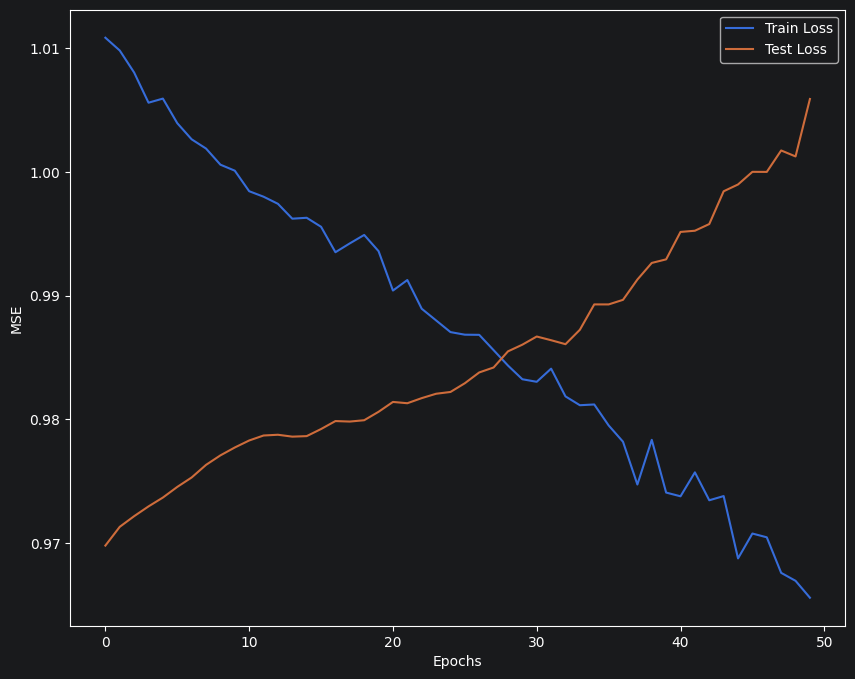

In [203]:
plt.figure(figsize=(10,8))
plt.plot(best_results['train_losses'], label="Train Loss")
plt.plot(best_results['val_losses'], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [162]:
split_data['y_scaler'].n_features_in_

1

In [226]:
# Define the sweep configuration
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "model_type": {"value": "deep_esn_gated_gru"},
        "learning_rate": {"min": 1e-5, "max": 1e-2, "distribution": "log_uniform_values"},
        "weight_decay": {"min": 1e-6, "max": 1e-3, "distribution": "log_uniform_values"},
        "reservoir_size": {"values": [500, 1000, 1500, 2000, 2500]},
        "spectral_radius": {"min": 0.5, "max": 1.5, "distribution": "log_uniform_values"},
        "reservoir_sparsity": {"min": 0.8, "max": 0.99, "distribution": "log_uniform_values"},
        "leak_rate": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "input_scale": {"min": 0.1, "max": 1.0, "distribution": "log_uniform_values"},
        "rnn_hidden_size": {"values": [64, 128, 256, 512, 1024]},
        "hidden_units": {"values": [[128, 128, 128], [256, 256], [512], [128, 128], [256, 256, 256]]},
        "trainer_batch_size": {"values": [32, 64, 128]},
        "num_epochs": {"value": 50},
        "loss_name": {"value": "mse"},
        "early_stopping_min_delta": {"value": 1e-6},
        "early_stopping_patience": {"value": 10},
        "use_scheduler": {"value": True},
    }
}

# Initialize the sweep
sweep_id = wandb.sweep(sweep_config, project="gru-timeseries-extra-features-sweep")

# Create the training function for the sweep
train_sweep = make_train_sweep(
    wandb_project_name="gated-esn-gru-sweeps",
    datasets=(train_ds, test_ds),
    device=device,
    input_spec=input_size,
    num_outputs=1,
    metrics_config=MetricsConfig(task="regression", names=["mse", "mae"])
)

# Run the sweep agent
wandb.agent(sweep_id, function=train_sweep, count=80)

Create sweep with ID: 7p7rte2a
Sweep URL: https://wandb.ai/sas073-bucknell-university/gru-timeseries-extra-features-sweep/sweeps/7p7rte2a


wandb: Agent Starting Run: pf3fzq00 with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [256, 256]
wandb: 	input_scale: 0.11732936805675565
wandb: 	leak_rate: 0.3155798002787848
wandb: 	learning_rate: 9.63183554845844e-05
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 500
wandb: 	reservoir_sparsity: 0.8967554801031604
wandb: 	rnn_hidden_size: 128
wandb: 	spectral_radius: 0.612716588759594
wandb: 	trainer_batch_size: 64
wandb: 	use_scheduler: True
wandb: 	weight_decay: 9.70322152003014e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.
wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_de

wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [256, 256], 'input_scale': 0.11732936805675565, 'leak_rate': 0.3155798002787848, 'learning_rate': 9.63183554845844e-05, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 500, 'reservoir_sparsity': 0.8967554801031604, 'rnn_hidden_size': 128, 'spectral_radius': 0.612716588759594, 'trainer_batch_size': 64, 'use_scheduler': True, 'weight_decay': 9.70322152003014e-05}
Run name set to: deep_esn_gated_gru_bs64_lr0.00010_h256x256_wd0.00010_m0.90
deep_esn_gated_gru
Epoch 0: Train Loss=1.0126,Val Loss=1.0672, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0126, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7470, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0672, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7094, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> A

wandb: Agent Starting Run: 9xleava4 with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [512]
wandb: 	input_scale: 0.4117872868796469
wandb: 	leak_rate: 0.3131072836744798
wandb: 	learning_rate: 0.0007072904955778325
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 2000
wandb: 	reservoir_sparsity: 0.9083145277861772
wandb: 	rnn_hidden_size: 128
wandb: 	spectral_radius: 0.6982482039201588
wandb: 	trainer_batch_size: 32
wandb: 	use_scheduler: True
wandb: 	weight_decay: 4.745938139609696e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [512], 'input_scale': 0.4117872868796469, 'leak_rate': 0.3131072836744798, 'learning_rate': 0.0007072904955778325, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 2000, 'reservoir_sparsity': 0.9083145277861772, 'rnn_hidden_size': 128, 'spectral_radius': 0.6982482039201588, 'trainer_batch_size': 32, 'use_scheduler': True, 'weight_decay': 4.745938139609696e-05}
Run name set to: deep_esn_gated_gru_bs32_lr0.00071_h512_wd0.00005_m0.90
deep_esn_gated_gru


...

Epoch 0: Train Loss=1.4305,Val Loss=1.0960, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.4305, device='cuda:0'), 'MeanAbsoluteError': tensor(0.9195, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0960, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7276, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0606,Val Loss=1.0629, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0606, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7733, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0629, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7329, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0439,Val Loss=1.0610, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError':

wandb: Agent Starting Run: l6vmz5mg with config:
wandb: 	early_stopping_min_delta: 1e-06
wandb: 	early_stopping_patience: 10
wandb: 	hidden_units: [256, 256]
wandb: 	input_scale: 0.3281464585623794
wandb: 	leak_rate: 0.2513111688463385
wandb: 	learning_rate: 1.853229976670295e-05
wandb: 	loss_name: mse
wandb: 	model_type: deep_esn_gated_gru
wandb: 	num_epochs: 50
wandb: 	reservoir_size: 500
wandb: 	reservoir_sparsity: 0.874208320204207
wandb: 	rnn_hidden_size: 1024
wandb: 	spectral_radius: 1.3840715526662264
wandb: 	trainer_batch_size: 128
wandb: 	use_scheduler: True
wandb: 	weight_decay: 2.7147029394183295e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'early_stopping_min_delta': 1e-06, 'early_stopping_patience': 10, 'hidden_units': [256, 256], 'input_scale': 0.3281464585623794, 'leak_rate': 0.2513111688463385, 'learning_rate': 1.853229976670295e-05, 'loss_name': 'mse', 'model_type': 'deep_esn_gated_gru', 'num_epochs': 50, 'reservoir_size': 500, 'reservoir_sparsity': 0.874208320204207, 'rnn_hidden_size': 1024, 'spectral_radius': 1.3840715526662264, 'trainer_batch_size': 128, 'use_scheduler': True, 'weight_decay': 2.7147029394183295e-05}
Run name set to: deep_esn_gated_gru_bs128_lr0.00002_h256x256_wd0.00003_m0.90
deep_esn_gated_gru


wandb: WARNING Config item 'trainer_batch_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'num_epochs' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_patience' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'early_stopping_min_delta' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'use_scheduler' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'model_type' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'hidden_units' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'rnn_hidden_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'reservoir_size' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'spectral_radius' was locked by 'sweep'

Epoch 0: Train Loss=1.0162,Val Loss=1.0720, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0162, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7519, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0720, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7158, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=1.0078,Val Loss=1.0743, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0078, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7471, device='cuda:0')}, Test: {'MeanSquaredError': tensor(1.0743, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7158, device='cuda:0')}
--> Saving checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=1.0070,Val Loss=1.0764, Val Acc=0.00%,Metrics: Train: {'MeanSquaredError': tensor(1.0070, device='cuda:0'), 'MeanAbsoluteError': tensor(0.7468, device='cuda:0')}, Test: {'MeanSquaredErr

## Just predicting price up or down

In [210]:
scaler = split_data['y_scaler']
y_train_og = scaler.inverse_transform(y_train)
y_val_og = scaler.inverse_transform(y_val)
y_test_og = scaler.inverse_transform(y_test)

y_train_class = np.where(y_train_og > 0, 1, 0)
y_val_class = np.where(y_val_og > 0, 1, 0)
y_test_class = np.where(y_test_og > 0, 1, 0)

train_class_ds = TensorDataset(X_train, torch.tensor(y_train_class, dtype=torch.long).squeeze())
val_class_ds = TensorDataset(X_val, torch.tensor(y_val_class, dtype=torch.long).squeeze())
test_class_ds = TensorDataset(X_test, torch.tensor(y_test_class, dtype=torch.long).squeeze())

In [212]:
class_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
    rnn_hidden_size=512
)

best_class = build_model(input_spec=input_size, config=class_config, num_outputs=2)

deep_best_trainer_config = TrainerConfig(
    optimizer_name=best_config['optimizer_name'],
    learning_rate=1e-5,
    weight_decay=1e-2,
    early_stopping_min_delta=best_config['early_stopping_min_delta'],
    early_stopping_patience=None,
    trainer_batch_size=best_config['trainer_batch_size'],
    evaluator_batch_size=best_config['evaluator_batch_size'],
    num_epochs=50,
    device=device,
)

print(best_more_features.num_parameters())

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_class_ds,
    eval_ds=val_class_ds,
    test_ds=test_class_ds,
    train_batch_size=deep_best_trainer_config.trainer_batch_size,
    eval_batch_size=deep_best_trainer_config.evaluator_batch_size,
    time_series=True
)

with Trainer(
    model=best_class,
    optimizer=make_optimizer(filter(lambda p: p.requires_grad, best_class.parameters()), deep_best_trainer_config),
    criterion=torch.nn.CrossEntropyLoss(),
    config=deep_best_trainer_config,
) as trainer:
    best_results = trainer.fit(train_loader, val_loader)

(11273281, 3713281)
Epoch 0: Train Loss=0.6935,Val Loss=0.6942, Val Acc=40.54%,Metrics: Train: None, Test: None
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1: Train Loss=0.6921,Val Loss=0.6937, Val Acc=50.00%,Metrics: Train: None, Test: None
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2: Train Loss=0.6906,Val Loss=0.6932, Val Acc=50.00%,Metrics: Train: None, Test: None
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3: Train Loss=0.6899,Val Loss=0.6929, Val Acc=50.68%,Metrics: Train: None, Test: None
--> Saving checkpoint: ./checkpoints/last.pt
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoi